✅ Dataset Loaded & Split for Evaluation
✅ Models Loaded Successfully

📊 Logistic Regression Model Report
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       377
           1       0.74      0.43      0.55        67

    accuracy                           0.89       444
   macro avg       0.82      0.70      0.74       444
weighted avg       0.88      0.89      0.88       444

Accuracy: 0.8919 | F1-Score: 0.5472 | AUC: 0.9120


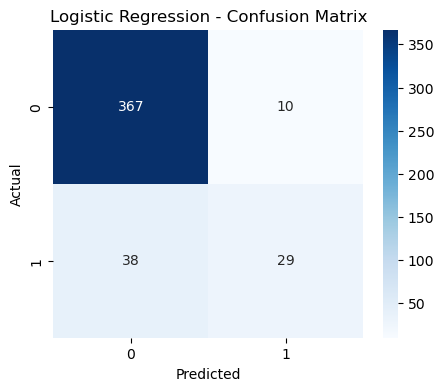


📊 Random Forest Model Report
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       377
           1       0.85      0.34      0.49        67

    accuracy                           0.89       444
   macro avg       0.87      0.67      0.71       444
weighted avg       0.89      0.89      0.87       444

Accuracy: 0.8919 | F1-Score: 0.4894 | AUC: 0.8815


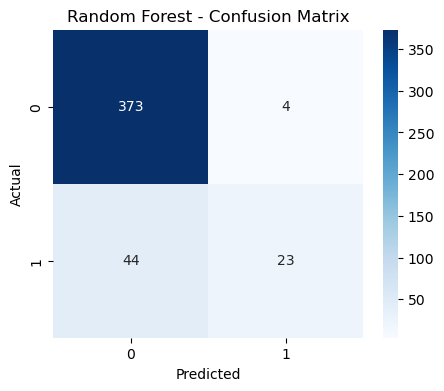

,Model,Accuracy,F1,AUC
0,Logistic Regression,0.891892,0.547170,0.911992
1,Random Forest,0.891892,0.489362,0.881468



✅ Model comparison complete!


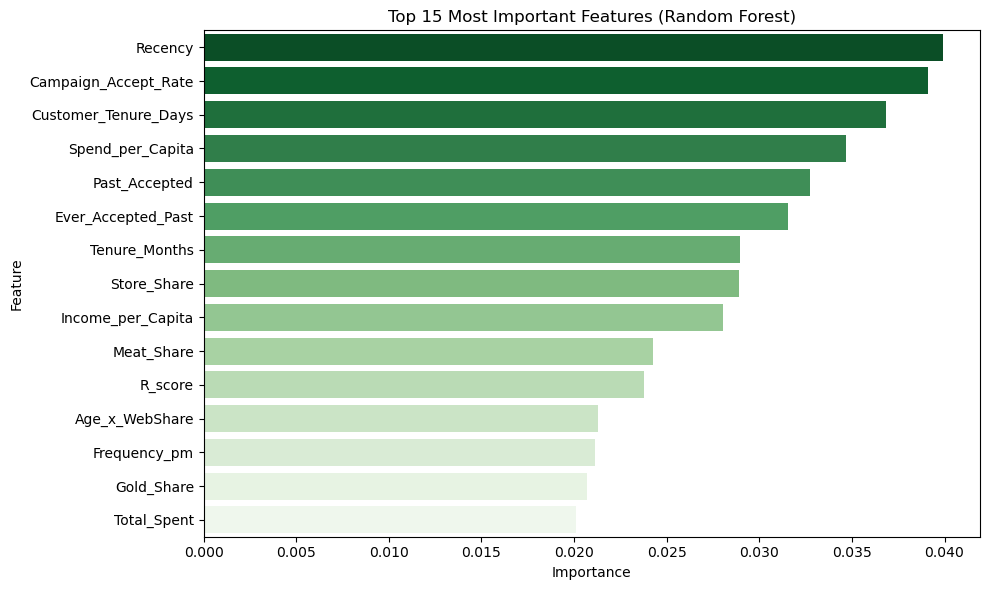


🔍 INTERPRETATION SUMMARY
1️⃣ Logistic Regression gives a linear baseline; coefficients indicate direction of influence.
2️⃣ Random Forest captures nonlinear relationships and interactions between features.
3️⃣ The feature importance chart shows which variables drive 'Response = Yes'.
   (e.g., higher income, lower recency, higher RFM scores often correlate with positive response.)
4️⃣ Use both models together for explainability + performance benchmarking.


In [8]:
# ================================================================
# TASK 2: EVALUATE AND INTERPRET ALL MODELS
# Models: Logistic Regression, Random Forest
# ================================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

# -----------------------------
# 2. LOAD DATA & PREPARE TEST SPLIT
# -----------------------------
df = pd.read_csv("customers_featured.csv")

# Ensure Response column is numeric
if df["Response"].dtype == "object":
    df["Response"] = df["Response"].map({"Yes": 1, "No": 0})

X = df.drop("Response", axis=1)
y = df["Response"]

# Recreate same train/test split used earlier
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Dataset Loaded & Split for Evaluation")

# -----------------------------
# 3. LOAD TRAINED MODELS
# -----------------------------
lr_model = joblib.load("results_lr/logistic_regression_model.pkl")
rf_model = joblib.load("results_rf/random_forest_model.pkl")

print("✅ Models Loaded Successfully")

# -----------------------------
# 4. EVALUATE BOTH MODELS
# -----------------------------
def evaluate_model(name, model, X_test, y_test):
    """Helper function to compute metrics and return results dict"""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    print(f"\n📊 {name} Model Report")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {acc:.4f} | F1-Score: {f1:.4f} | AUC: {roc_auc:.4f}")

    # Plot Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {"Model": name, "Accuracy": acc, "F1": f1, "AUC": roc_auc}

# Evaluate both
lr_results = evaluate_model("Logistic Regression", lr_model, X_test, y_test)
rf_results = evaluate_model("Random Forest", rf_model, X_test, y_test)

# -----------------------------
# 5. COMPARE RESULTS SIDE-BY-SIDE
# -----------------------------
comparison_df = pd.DataFrame([lr_results, rf_results])
display(comparison_df.style.background_gradient(cmap="Greens", subset=["Accuracy", "F1", "AUC"]))
print("\n✅ Model comparison complete!")

# -----------------------------
# 6. FEATURE IMPORTANCE (RANDOM FOREST)
# -----------------------------
# Extract preprocessed feature names
preprocessor = rf_model.named_steps["preprocessor"]
cat_features = preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(
    preprocessor.transformers_[1][2]
)
num_features = preprocessor.transformers_[0][2]
feature_names = list(num_features) + list(cat_features)

# Get feature importances
importances = rf_model.named_steps["classifier"].feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Save for report
importance_df.to_csv("results_rf/feature_importance_evaluation.csv", index=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature", palette="Greens_r")
plt.title("Top 15 Most Important Features (Random Forest)")
plt.tight_layout()
plt.show()

# -----------------------------
# 7. INTERPRETATION INSIGHTS
# -----------------------------
print("\n🔍 INTERPRETATION SUMMARY")
print("1️⃣ Logistic Regression gives a linear baseline; coefficients indicate direction of influence.")
print("2️⃣ Random Forest captures nonlinear relationships and interactions between features.")
print("3️⃣ The feature importance chart shows which variables drive 'Response = Yes'.")
print("   (e.g., higher income, lower recency, higher RFM scores often correlate with positive response.)")
print("4️⃣ Use both models together for explainability + performance benchmarking.")